In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: smokenandos
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:32<00:00, 22.3MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms

import torch.nn as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device available: ", device)

Device available:  cuda


In [ ]:
image_path = []
labels = []


for i in os.listdir("/content/animal-faces/afhq/"):

  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):

    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      labels.append(label)
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")


data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])

print(data_df["labels"].unique())
data_df.head()



['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
1,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
3,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [ ]:
train = data_df.sample(frac = 0.9)
test = data_df.drop(train.index)

val = test.sample(frac = 0.4)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(14517, 2)
(645, 2)
(968, 2)


In [ ]:
test

,image_path,labels
11,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
13,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
16,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
19,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
20,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
...,...,...
16095,/content/animal-faces/afhq/train/wild/flickr_w...,wild
16102,/content/animal-faces/afhq/train/wild/flickr_w...,wild
16108,/content/animal-faces/afhq/train/wild/pixabay_...,wild
16109,/content/animal-faces/afhq/train/wild/flickr_w...,wild


In [ ]:
label_encoder = LabelEncoder()

label_encoder.fit(data_df["labels"])


transform = transforms.Compose([
    transforms.Resize([132, 132]),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)

])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe["labels"])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label


In [ ]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)

In [ ]:
train_dataset.__len__()

14517

In [ ]:
train_dataset.__getitem__(9)

(tensor([[[0.5804, 0.5804, 0.5882,  ..., 0.7725, 0.7725, 0.7725],
          [0.5373, 0.5373, 0.5412,  ..., 0.7294, 0.7255, 0.7255],
          [0.4863, 0.4863, 0.4902,  ..., 0.6784, 0.6745, 0.6745],
          ...,
          [0.0824, 0.0863, 0.0510,  ..., 0.5176, 0.5176, 0.5098],
          [0.1216, 0.0941, 0.0745,  ..., 0.5176, 0.5176, 0.5098],
          [0.2667, 0.1490, 0.0902,  ..., 0.5216, 0.5176, 0.5098]],
 
         [[0.5765, 0.5765, 0.5843,  ..., 0.7686, 0.7686, 0.7686],
          [0.5373, 0.5373, 0.5412,  ..., 0.7255, 0.7216, 0.7216],
          [0.4941, 0.4941, 0.4941,  ..., 0.6745, 0.6706, 0.6706],
          ...,
          [0.0784, 0.0784, 0.0471,  ..., 0.4784, 0.4784, 0.4706],
          [0.1098, 0.0863, 0.0745,  ..., 0.4784, 0.4784, 0.4706],
          [0.2510, 0.1333, 0.0784,  ..., 0.4824, 0.4784, 0.4706]],
 
         [[0.5961, 0.5961, 0.6039,  ..., 0.7882, 0.7882, 0.7882],
          [0.5608, 0.5608, 0.5647,  ..., 0.7451, 0.7412, 0.7412],
          [0.5216, 0.5216, 0.5216,  ...,

In [ ]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

In [ ]:
label_encoder.inverse_transform([1])

array(['dog'], dtype=object)

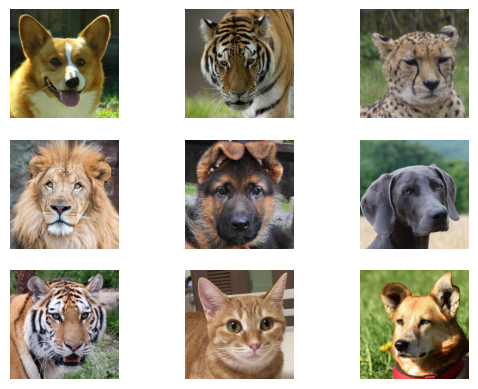

In [ ]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

plt.show()

In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10


In [ ]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)


In [ ]:
import torch.nn as nn
relu = nn.ReLU()

class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 4, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 4, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 4, padding = 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128 * 15 * 15), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x) # 32, 127, 127. Convolution doesn't change the size
    x = self.pooling(x) # 32, 63, 63
    x = self.relu(x) #

    x = self.conv2(x) # 63, 63, 63
    x = self.pooling(x) # 63, 32, 32
    x = self.relu(x)

    x = self.conv3(x) # 127, 32, 32
    x = self.pooling(x) # 127, 15, 15
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x



In [ ]:
import torch.nn as nn

model = Net().to(device)

In [ ]:
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 127, 127]           1,568
         MaxPool2d-2           [-1, 32, 63, 63]               0
              ReLU-3           [-1, 32, 63, 63]               0
            Conv2d-4           [-1, 64, 62, 62]          32,832
         MaxPool2d-5           [-1, 64, 31, 31]               0
              ReLU-6           [-1, 64, 31, 31]               0
            Conv2d-7          [-1, 128, 30, 30]         131,200
         MaxPool2d-8          [-1, 128, 15, 15]               0
              ReLU-9          [-1, 128, 15, 15]               0
          Flatten-10                [-1, 28800]               0
           Linear-11                  [-1, 128]       3,686,528
           Linear-12                    [-1, 3]             387
Total params: 3,852,515
Trainable params: 3,852,515
Non-trainable params: 0
---------------------------

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [32]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:

    optimizer.zero_grad()
    outputs = model(inputs)

    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc


  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch + 1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy: {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy: {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
         ''')





Epoch 1/10, Train Loss: 0.106 Train Accuracy: 99.69
            Validation Loss: 0.0067 Validation Accuracy: 96.2791
         
Epoch 2/10, Train Loss: 0.1019 Train Accuracy: 99.5798
            Validation Loss: 0.0044 Validation Accuracy: 97.0543
         
Epoch 3/10, Train Loss: 0.0979 Train Accuracy: 99.6694
            Validation Loss: 0.0058 Validation Accuracy: 96.2791
         
Epoch 4/10, Train Loss: 0.0624 Train Accuracy: 99.814
            Validation Loss: 0.0051 Validation Accuracy: 96.5891
         
Epoch 5/10, Train Loss: 0.0652 Train Accuracy: 99.7589
            Validation Loss: 0.0032 Validation Accuracy: 97.9845
         
Epoch 6/10, Train Loss: 0.0523 Train Accuracy: 99.8278
            Validation Loss: 0.0044 Validation Accuracy: 97.0543
         
Epoch 7/10, Train Loss: 0.0688 Train Accuracy: 99.7245
            Validation Loss: 0.0072 Validation Accuracy: 95.5039
         
Epoch 8/10, Train Loss: 0.085 Train Accuracy: 99.7038
            Validation Loss: 0.0053 Vali

In [22]:
print(outputs.shape)

torch.Size([5, 3])


In [33]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")






Accuracy Score: 95.7645 and Loss is 0.0134


In [24]:
print(acc)

7


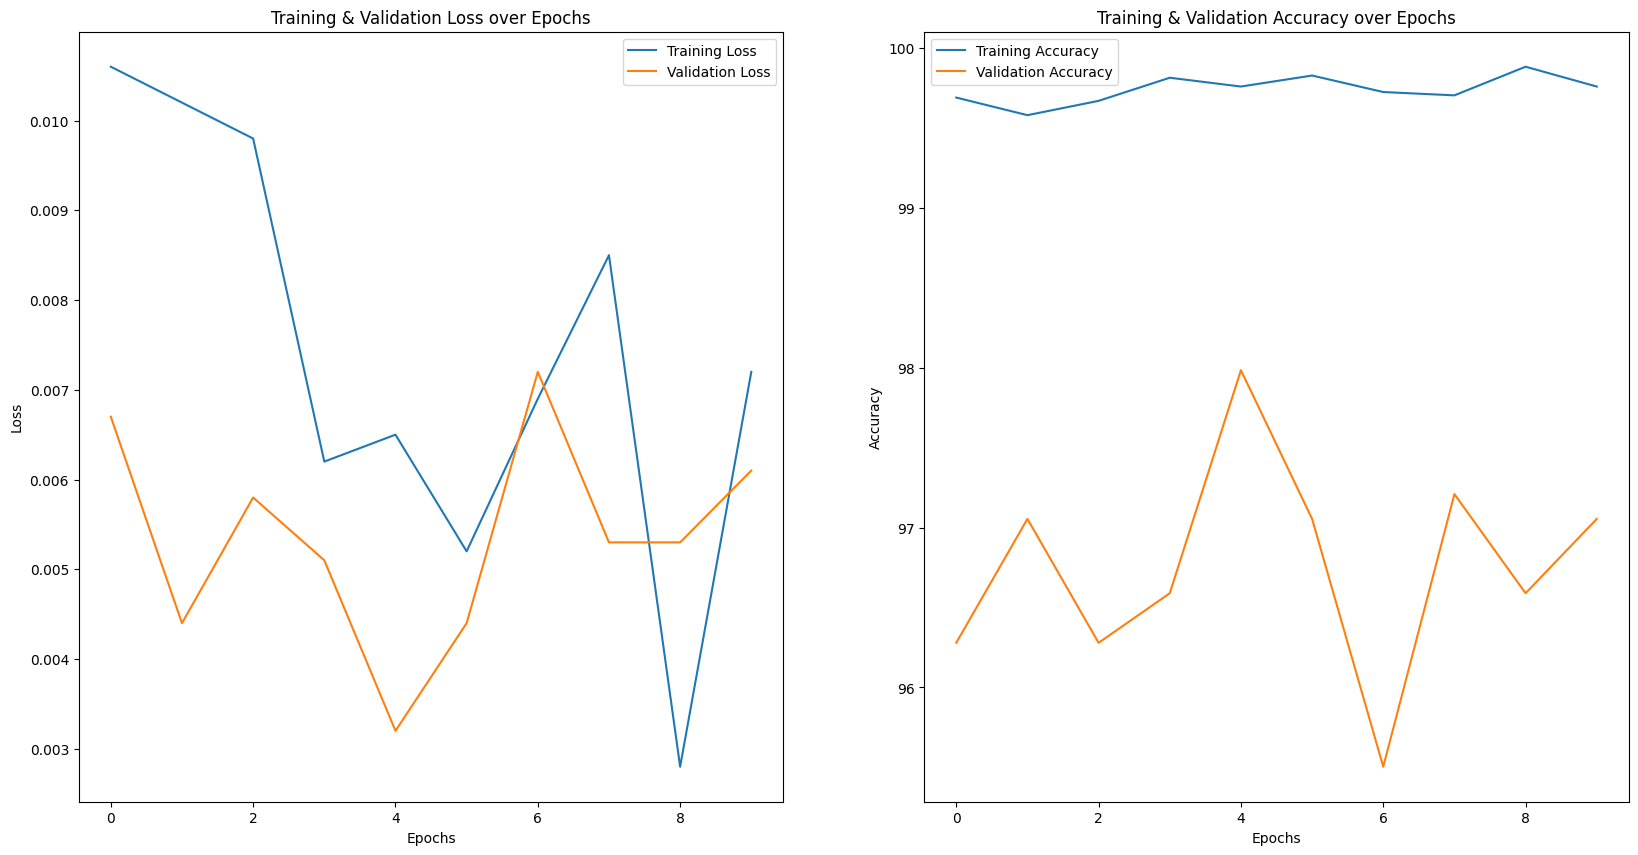

In [34]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = [20, 10])

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training & Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training & Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [57]:
# 1: Read image
# 2 Transform using transform object
# 3: Predict through model
# 4: Inverse transform by label encoder

def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis = 1).item()

  return label_encoder.inverse_transform([output])



In [58]:
predict_image("/content/Catfit.png")

array(['cat'], dtype=object)